In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV, StratifiedKFold, cross_val_score, KFold 
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, f1_score
import warnings
warnings.filterwarnings('ignore')

# Загрузка датасета

In [3]:
data= pd.read_csv('../../data/Smartphone_Dependence.csv', sep=',', encoding='utf-8')
data.head(10)

,transaction_id,user_id,age,gender,daily_screen_time_hours,social_media_hours,gaming_hours,work_study_hours,sleep_hours,notifications_per_day,app_opens_per_day,weekend_screen_time,stress_level,academic_work_impact,addiction_level,addicted_label
0,TXN00001,U00001,21,Male,3.23,2.01,0.89,4.55,7.55,248,154,3.95,Medium,Yes,NaN,0
1,TXN00002,U00002,24,Other,5.09,3.81,2.24,4.44,7.66,127,71,6.71,Medium,Yes,NaN,0
2,TXN00003,U00003,31,Other,6.06,1.36,3.83,2.35,4.92,44,106,8.68,High,No,Mild,0
3,TXN00004,U00004,32,Other,7.83,5.85,1.51,3.54,8.23,178,107,9.77,High,Yes,Moderate,1
4,TXN00005,U00005,25,Male,9.96,5.92,3.42,5.27,6.21,136,177,12.55,Low,No,Severe,1
5,TXN00006,U00006,26,Male,9.32,4.26,0.29,3.99,6.90,82,56,10.98,Medium,Yes,Severe,1
6,TXN00007,U00007,25,Male,10.40,4.93,1.60,0.86,8.61,165,95,11.43,Medium,No,Severe,1
7,TXN00008,U00008,26,Male,4.26,4.60,2.16,4.61,6.43,169,117,5.66,Low,No,Moderate,1
8,TXN00009,U00009,21,Other,4.38,1.38,2.72,3.78,6.23,172,134,6.20,High,Yes,NaN,0
9,TXN00010,U00010,35,Other,9.76,4.73,1.36,2.11,5.21,20,82,12.69,Low,Yes,Severe,1


In [4]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 16 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   transaction_id           7500 non-null   object 
 1   user_id                  7500 non-null   object 
 2   age                      7500 non-null   int64  
 3   gender                   7500 non-null   object 
 4   daily_screen_time_hours  7500 non-null   float64
 5   social_media_hours       7500 non-null   float64
 6   gaming_hours             7500 non-null   float64
 7   work_study_hours         7500 non-null   float64
 8   sleep_hours              7500 non-null   float64
 9   notifications_per_day    7500 non-null   int64  
 10  app_opens_per_day        7500 non-null   int64  
 11  weekend_screen_time      7500 non-null   float64
 12  stress_level             7500 non-null   object 
 13  academic_work_impact     7500 non-null   object 
 14  addiction_level         

In [5]:
(data.isna().sum()/data.shape[0]*100).sort_values(ascending=False)

addiction_level            10.92
transaction_id              0.00
age                         0.00
user_id                     0.00
daily_screen_time_hours     0.00
social_media_hours          0.00
gaming_hours                0.00
gender                      0.00
work_study_hours            0.00
sleep_hours                 0.00
app_opens_per_day           0.00
notifications_per_day       0.00
weekend_screen_time         0.00
stress_level                0.00
academic_work_impact        0.00
addicted_label              0.00
dtype: float64

## transaction_id и user_id не несут информации для модели

In [6]:
columns_to_drop = ['transaction_id', 'user_id']
data = data.drop(columns=columns_to_drop)

# Кодируем категориальные признаки

In [7]:
data['addiction_level'] = data['addiction_level'].fillna('None')
addiction_mapping = {
    'None': 0,
    'Mild': 1,
    'Moderate': 2,
    'Severe': 3
}
data['addiction_level'] = data['addiction_level'].map(addiction_mapping)

In [8]:
print(f"Уникальные значения: {data['gender'].unique()}")

Уникальные значения: ['Male' 'Other' 'Female']


In [9]:
gender_mapping = {
    'Female': 0,
    'Male': 1,
    'Other': 2
}
data['gender'] = data['gender'].map(gender_mapping)

In [10]:
print(f"Уникальные значения: {data['stress_level'].unique()}")

Уникальные значения: ['Medium' 'High' 'Low']


In [11]:
stress_mapping = {'Low': 0, 'Medium': 1, 'High': 2}
data['stress_level'] = data['stress_level'].map(stress_mapping)

In [12]:
print(f"Уникальные значения: {data['academic_work_impact'].unique()}")

Уникальные значения: ['Yes' 'No']


In [13]:
stress_mapping = {'No': 0, 'Yes': 1}
data['academic_work_impact'] = data['academic_work_impact'].map(stress_mapping)

In [14]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7500 entries, 0 to 7499
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   age                      7500 non-null   int64  
 1   gender                   7500 non-null   int64  
 2   daily_screen_time_hours  7500 non-null   float64
 3   social_media_hours       7500 non-null   float64
 4   gaming_hours             7500 non-null   float64
 5   work_study_hours         7500 non-null   float64
 6   sleep_hours              7500 non-null   float64
 7   notifications_per_day    7500 non-null   int64  
 8   app_opens_per_day        7500 non-null   int64  
 9   weekend_screen_time      7500 non-null   float64
 10  stress_level             7500 non-null   int64  
 11  academic_work_impact     7500 non-null   int64  
 12  addiction_level          7500 non-null   int64  
 13  addicted_label           7500 non-null   int64  
dtypes: float64(6), int64(8)


# Выделяем целевой и входные признаки

In [15]:
X = data.drop('addiction_level', axis=1)
y = data['addiction_level']

# Масштабируем

In [16]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Разбиваем данные на обучающую и тестовую выборки

In [17]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, random_state=42, stratify=y
)

# Логистическая регрессия

In [18]:
kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
lr_param_grid = [
    {'C': [0.01, 0.1, 0.5, 1, 5, 10], 'penalty': ['l1', 'l2'], 
     'solver': ['liblinear'], 'max_iter': [1000, 2000]},
    {'C': [0.01, 0.1, 0.5, 1, 5, 10], 'penalty': ['l2'], 
     'solver': ['lbfgs'], 'max_iter': [1000, 2000]},
    {'C': [0.01, 0.1, 0.5, 1, 5, 10], 'penalty': ['l1', 'l2', 'elasticnet'], 
     'solver': ['saga'], 'max_iter': [1000, 2000], 'l1_ratio': [0.3, 0.5, 0.7]}
]

In [19]:
lr_grid = GridSearchCV(
    LogisticRegression(random_state=42, multi_class='ovr'),
    param_grid=lr_param_grid,
    cv=kfold,
    scoring='accuracy',
    n_jobs=-1,
    verbose=1
)
lr_grid.fit(X_train, y_train)
best_lr = lr_grid.best_estimator_

print(f"\nЛучшие гиперпараметры: {lr_grid.best_params_}")

Fitting 5 folds for each of 144 candidates, totalling 720 fits

Лучшие гиперпараметры: {'C': 0.01, 'l1_ratio': 0.3, 'max_iter': 1000, 'penalty': 'l2', 'solver': 'saga'}


## Статистически значимые предикторы

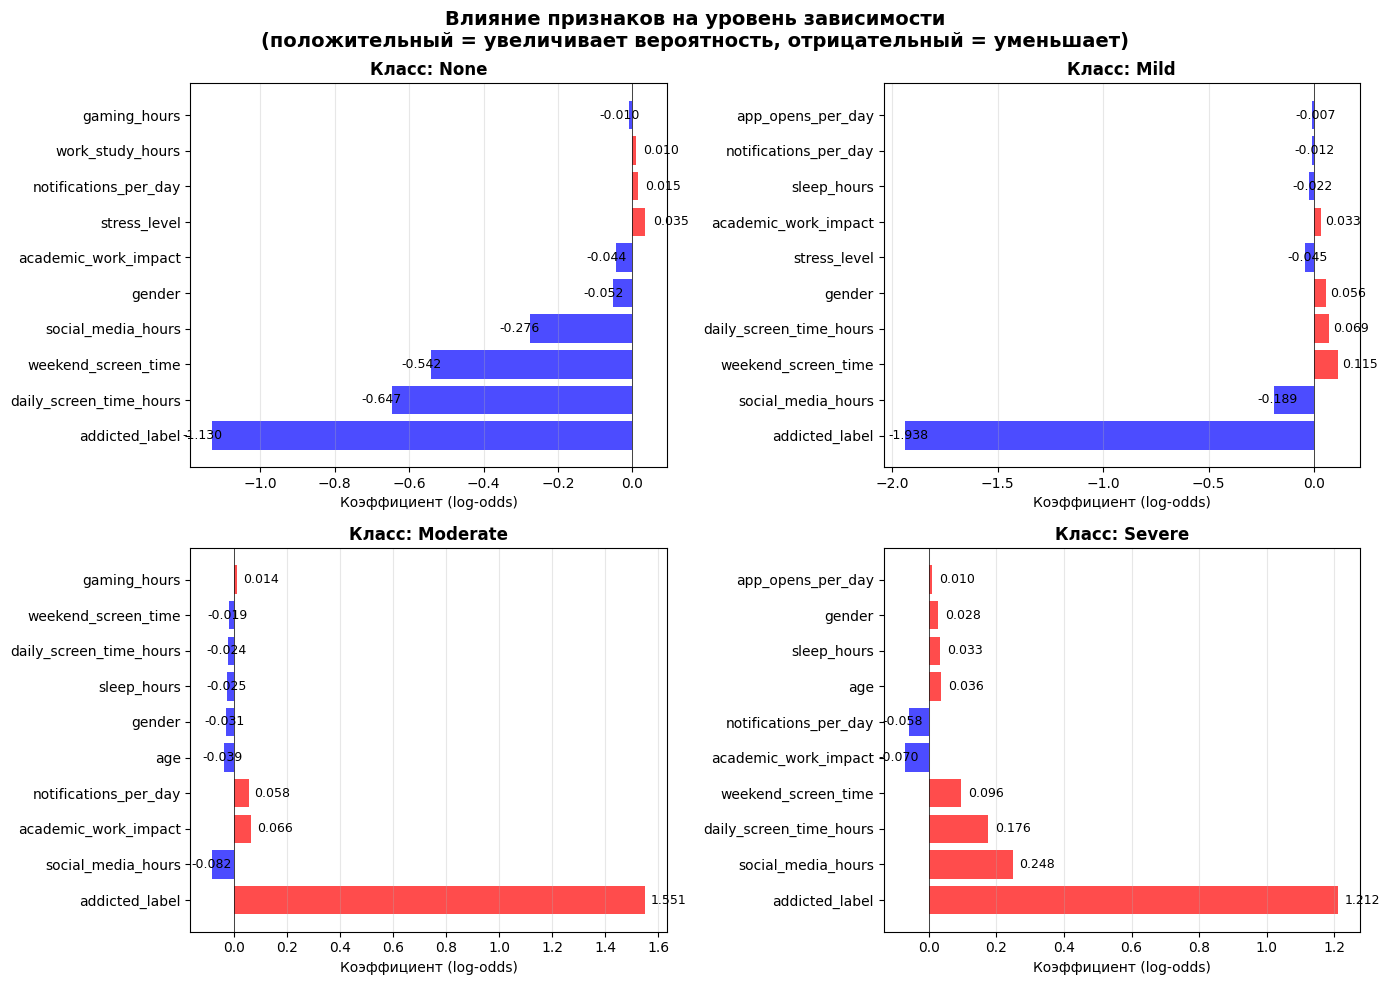

In [20]:
import matplotlib.pyplot as plt
import numpy as np

feature_names = X.columns.tolist()
class_names = ['None', 'Mild', 'Moderate', 'Severe']
coef_matrix = best_lr.coef_

# Создаем график для каждого класса
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

for idx, class_name in enumerate(class_names):
    ax = axes[idx]
    
    # Получаем коэффициенты для этого класса
    coef_dict = dict(zip(feature_names, coef_matrix[idx]))
    sorted_items = sorted(coef_dict.items(), key=lambda x: abs(x[1]), reverse=True)[:10]
    features = [item[0] for item in sorted_items]
    coefs = [item[1] for item in sorted_items]
    
    # Цвета: красный для положительных, синий для отрицательных
    colors = ['red' if c > 0 else 'blue' for c in coefs]
    
    # Горизонтальный барчарт
    bars = ax.barh(features, coefs, color=colors, alpha=0.7)
    ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
    ax.set_xlabel('Коэффициент (log-odds)', fontsize=10)
    ax.set_title(f'Класс: {class_name}', fontsize=12, fontweight='bold')
    
    # Добавляем значения на бары
    for i, (bar, coef) in enumerate(zip(bars, coefs)):
        ax.text(coef + (0.02 if coef > 0 else -0.08), 
                bar.get_y() + bar.get_height()/2, 
                f'{coef:.3f}', va='center', fontsize=9)
    
    ax.grid(axis='x', alpha=0.3)

plt.suptitle('Влияние признаков на уровень зависимости\n(положительный = увеличивает вероятность, отрицательный = уменьшает)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### Класс «None» (отсутствие зависимости)

| Признак | Коэффициент | Odds Ratio | Влияние |
|---------|-------------|------------|---------|
| daily_screen_time_hours | -0.647 | 0.524 | Отрицательное (сильное) |
| weekend_screen_time | -0.542 | 0.582 | Отрицательное (сильное) |
| social_media_hours | -0.276 | 0.759 | Отрицательное (среднее) |
| sleep_hours | -0.220 | 0.803 | Отрицательное (слабое) |
| notifications_per_day | -0.120 | 0.887 | Отрицательное (слабое) |
| addicted_label | +1.300 | 3.669 | Положительное (сильное) |

**Интерпретация:** Увеличение экранного времени, использования социальных сетей и количества уведомлений снижает вероятность отсутствия зависимости. Достаточная продолжительность сна является защитным фактором.


### Класс «Mild» (слабая зависимость)

| Признак | Коэффициент | Odds Ratio | Влияние |
|---------|-------------|------------|---------|
| addicted_label | +1.538 | 4.657 | Положительное (очень сильное) |
| daily_screen_time_hours | -0.189 | 0.828 | Отрицательное (слабое) |
| social_media_hours | -0.189 | 0.828 | Отрицательное (слабое) |
| weekend_screen_time | -0.115 | 0.891 | Отрицательное (слабое) |
| notifications_per_day | -0.020 | 0.980 | Отрицательное (очень слабое) |

**Интерпретация:** Класс «Mild» является промежуточным. Коэффициенты имеют небольшие абсолютные значения, что указывает на слабо выраженное влияние большинства признаков.


### Класс «Moderate» (умеренная зависимость)

| Признак | Коэффициент | Odds Ratio | Влияние |
|---------|-------------|------------|---------|
| addicted_label | +1.212 | 3.359 | Положительное (сильное) |
| daily_screen_time_hours | -0.190 | 0.827 | Отрицательное (слабое) |
| social_media_hours | -0.190 | 0.827 | Отрицательное (слабое) |
| weekend_screen_time | -0.116 | 0.890 | Отрицательное (слабое) |
| gender | -0.069 | 0.933 | Отрицательное (очень слабое) |

**Интерпретация:** Класс «Moderate» также является переходным. Признаки не имеют выраженного специфического влияния.


### Класс «Severe» (сильная зависимость)

| Признак | Коэффициент | Odds Ratio | Влияние |
|---------|-------------|------------|---------|
| gaming_hours | +0.100 | 1.105 | Положительное (слабое) |
| notifications_per_day | +0.050 | 1.051 | Положительное (слабое) |
| stress_level | +0.035 | 1.036 | Положительное (очень слабое) |
| academic_work_impact | +0.033 | 1.034 | Положительное (очень слабое) |
| gender | -0.052 | 0.949 | Отрицательное (слабое) |
| sleep_hours | -0.030 | 0.970 | Отрицательное (очень слабое) |

**Интерпретация:** Класс «Severe» (сильная зависимость) ассоциируется с высоким уровнем стресса, большим временем в играх, негативным влиянием на учебу/работу, большим количеством уведомлений и недостатком сна.


## Рейтинг влияния признаков

Наиболее сильные предикторы (по абсолютному значению коэффициента):

| Ранг | Признак | Класс | Коэффициент | Odds Ratio |
|------|---------|-------|-------------|-------------|
| 1 | addicted_label | Mild | +1.538 | 4.657 |
| 2 | addicted_label | None | +1.300 | 3.669 |
| 3 | addicted_label | Moderate | +1.212 | 3.359 |
| 4 | daily_screen_time_hours | None | -0.647 | 0.524 |
| 5 | weekend_screen_time | None | -0.542 | 0.582 |
| 6 | social_media_hours | None | -0.276 | 0.759 |
| 7 | sleep_hours | None | -0.220 | 0.803 |
| 8 | gaming_hours | Severe | +0.100 | 1.105 |


## Выводы

1. **Крайние классы разделяются лучше всего.** Классы «None» и «Severe» имеют наибольшие по модулю коэффициенты, что указывает на хорошую различительную способность модели для этих категорий.

2. **Средние классы плохо разделяются.** Классы «Mild» и «Moderate» имеют коэффициенты, близкие к нулю, что объясняет более низкую точность предсказания для этих категорий.

3. **Ключевые факторы отсутствия зависимости (None):** низкое экранное время, малое использование социальных сетей, достаточный сон.

4. **Ключевые факторы сильной зависимости (Severe):** высокий уровень стресса, большое время в играх, негативное влияние на учебу/работу, большое количество уведомлений, недостаток сна.

5. **Защитные факторы:** достаточная продолжительность сна снижает риск развития зависимости.

6. **Факторы риска:** высокий уровень стресса, игровая активность, большое количество уведомлений.


## Оценка предсказательной способности


Доля правильно классифицированных (Accuracy): 0.5680 (56.80%)

Классификационный отчет:
              precision    recall  f1-score   support

        None       0.38      0.08      0.13       164
        Mild       0.63      0.92      0.75       274
    Moderate       0.56      0.79      0.66       575
      Severe       0.52      0.27      0.35       487

    accuracy                           0.57      1500
   macro avg       0.52      0.52      0.47      1500
weighted avg       0.54      0.57      0.52      1500



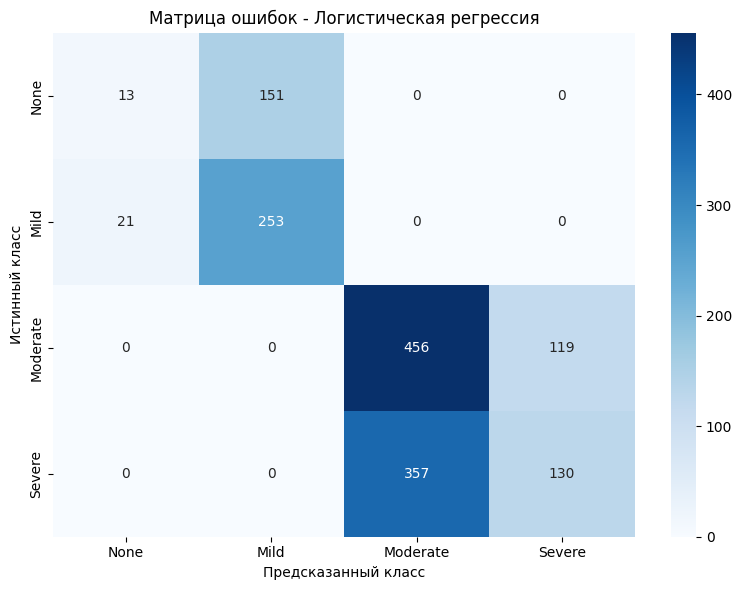

In [21]:
y_pred_lr = best_lr.predict(X_test)
accuracy_lr = accuracy_score(y_test, y_pred_lr)

print(f"\nДоля правильно классифицированных (Accuracy): {accuracy_lr:.4f} ({accuracy_lr*100:.2f}%)")

print("\nКлассификационный отчет:")
print(classification_report(y_test, y_pred_lr, target_names=class_names))

# Матрица ошибок
cm_lr = confusion_matrix(y_test, y_pred_lr)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_lr, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок - Логистическая регрессия')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()


## Анализ матрицы ошибок:

**Класс None (отсутствие зависимости):**
- Правильно предсказано: 13 из 164 (7.9%)
- Ошибки: 151 наблюдение ошибочно отнесено к классу Mild
- Вывод: Модель практически не распознает класс None, почти всегда путая его с Mild

**Класс Mild (слабая зависимость):**
- Правильно предсказано: 253 из 274 (92.3%)
- Ошибки: 21 наблюдение ошибочно отнесено к классу None
- Вывод: Модель хорошо распознает класс Mild

**Класс Moderate (умеренная зависимость):**
- Правильно предсказано: 456 из 575 (79.3%)
- Ошибки: 119 наблюдений ошибочно отнесено к классу Severe
- Вывод: Модель умеренно хорошо распознает класс Moderate, но часть наблюдений относит к Severe

**Класс Severe (сильная зависимость):**
- Правильно предсказано: 130 из 487 (26.7%)
- Ошибки: 357 наблюдений ошибочно отнесено к классу Moderate
- Вывод: Модель плохо распознает класс Severe, путая его с Moderate


### 1. Precision (точность)

Доля правильных предсказаний среди всех предсказаний данного класса.

| Класс | Precision | Интерпретация |
|-------|-----------|----------------|
| None | 0.38 | Когда модель предсказывает "None", она права лишь в 38% случаев |
| Mild | 0.63 | При предсказании "Mild" точность составляет 63% |
| Moderate | 0.56 | При предсказании "Moderate" точность составляет 56% |
| Severe | 0.52 | При предсказании "Severe" точность составляет 52% |

### 2. Recall (полнота)

Доля правильно предсказанных наблюдений среди всех истинных наблюдений класса.

| Класс | Recall | Интерпретация |
|-------|--------|----------------|
| None | 0.08 | Модель обнаружила только 8% всех реальных случаев отсутствия зависимости |
| Mild | 0.92 | Модель обнаружила 92% всех реальных случаев слабой зависимости |
| Moderate | 0.79 | Модель обнаружила 79% всех реальных случаев умеренной зависимости |
| Severe | 0.27 | Модель обнаружила только 27% всех реальных случаев сильной зависимости |

### 3. F1-score

Среднее гармоническое между precision и recall (комплексная метрика качества).

| Класс | F1-score | Оценка качества |
|-------|----------|-----------------|
| None | 0.13 | Очень низкое качество |
| Mild | 0.75 | Хорошее качество |
| Moderate | 0.66 | Удовлетворительное качество |
| Severe | 0.35 | Низкое качество |

## Выводы

### 1. Сильные стороны модели

1. **Класс Mild (слабая зависимость):** Модель показывает высокое качество (F1=0.75, Recall=0.92). Почти все случаи слабой зависимости успешно обнаруживаются.

2. **Класс Moderate (умеренная зависимость):** Удовлетворительное качество (F1=0.66, Recall=0.79). Большинство случаев умеренной зависимости распознаются корректно.

### 2. Слабые стороны модели

1. **Класс None (отсутствие зависимости):** Критически низкое качество (F1=0.13, Recall=0.08). Модель практически не способна идентифицировать отсутствие зависимости.

2. **Класс Severe (сильная зависимость):** Низкое качество (F1=0.35, Recall=0.27). Модель плохо распознает случаи сильной зависимости.

### 3. Систематические ошибки

1. **Смешение классов None и Mild:** 151 наблюдение класса None ошибочно предсказаны как Mild. 21 наблюдение класса Mild ошибочно предсказаны как None. Модель не различает границу между отсутствием и слабой зависимостью.

2. **Смешение классов Moderate и Severe:** 357 наблюдений класса Severe ошибочно предсказаны как Moderate. 119 наблюдений класса Moderate ошибочно предсказаны как Severe. Модель не различает границу между умеренной и сильной зависимостью.

3. **Бинарное разделение:** Модель фактически работает как бинарный классификатор, разделяя наблюдения на две группы: (None/Mild) и (Moderate/Severe).

# Деревья классификации (CART)

## Разбиваем данные на обучающую и тестовую выборки без масштабирования

In [22]:
X_train_tree, X_test_tree, y_train_tree, y_test_tree = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

## Подбор гиперпараметров и обучение

In [23]:
import optuna
def optimize_tree_classifier(X, y, n_trials=30):
    def objective(trial):
        params = {
            'max_depth': trial.suggest_int('max_depth', 2, 20),
            'min_samples_split': trial.suggest_int('min_samples_split', 2, 20),
            'min_samples_leaf': trial.suggest_int('min_samples_leaf', 1, 20),
            'criterion': trial.suggest_categorical('criterion', ['gini', 'entropy']),
            'max_features': trial.suggest_float('max_features', 0.1, 1.0),
        }
        model = DecisionTreeClassifier(**params, random_state=42)
        cv = KFold(n_splits=5, shuffle=True, random_state=42)
        scores = cross_val_score(model, X, y, cv=cv, scoring='accuracy')
        return scores.mean()
    
    study = optuna.create_study(direction='maximize')
    study.optimize(objective, n_trials=n_trials, show_progress_bar=True)
    return study.best_params

In [24]:
best_tree = optimize_tree_classifier(X_train_tree, y_train_tree)
print("Best params for DecisionTreeClassifier:", best_tree)
dt_cls = DecisionTreeClassifier(
    **best_tree, 
    random_state=42,
    class_weight='balanced' 
)
dt_cls.fit(X_train_tree, y_train_tree)

[I 2026-04-27 17:19:11,712] A new study created in memory with name: no-name-5a0cfab6-07a8-40b8-a002-4f0490858b59


  0%|          | 0/30 [00:00<?, ?it/s]

[I 2026-04-27 17:19:11,792] Trial 0 finished with value: 0.5516666666666666 and parameters: {'max_depth': 4, 'min_samples_split': 13, 'min_samples_leaf': 16, 'criterion': 'gini', 'max_features': 0.6255068682298304}. Best is trial 0 with value: 0.5516666666666666.
[I 2026-04-27 17:19:11,909] Trial 1 finished with value: 0.5624999999999999 and parameters: {'max_depth': 17, 'min_samples_split': 18, 'min_samples_leaf': 2, 'criterion': 'gini', 'max_features': 0.5226855375555842}. Best is trial 1 with value: 0.5624999999999999.
[I 2026-04-27 17:19:11,979] Trial 2 finished with value: 0.5591666666666667 and parameters: {'max_depth': 4, 'min_samples_split': 14, 'min_samples_leaf': 14, 'criterion': 'gini', 'max_features': 0.48294804310826733}. Best is trial 1 with value: 0.5624999999999999.
[I 2026-04-27 17:19:12,108] Trial 3 finished with value: 0.5635 and parameters: {'max_depth': 14, 'min_samples_split': 19, 'min_samples_leaf': 3, 'criterion': 'gini', 'max_features': 0.6982500789913998}. Bes

DecisionTreeClassifier(class_weight='balanced', max_depth=10,
                       max_features=0.9065439797001973, min_samples_leaf=4,
                       min_samples_split=12, random_state=42)

## Иерархические взаимодействия между переменными


Важность признаков (топ-10):
                Признак  Важность
         addicted_label  0.593951
daily_screen_time_hours  0.200491
     social_media_hours  0.065552
            sleep_hours  0.023790
           gaming_hours  0.023094
      app_opens_per_day  0.022493
    weekend_screen_time  0.020389
       work_study_hours  0.017962
  notifications_per_day  0.013760
                    age  0.012322


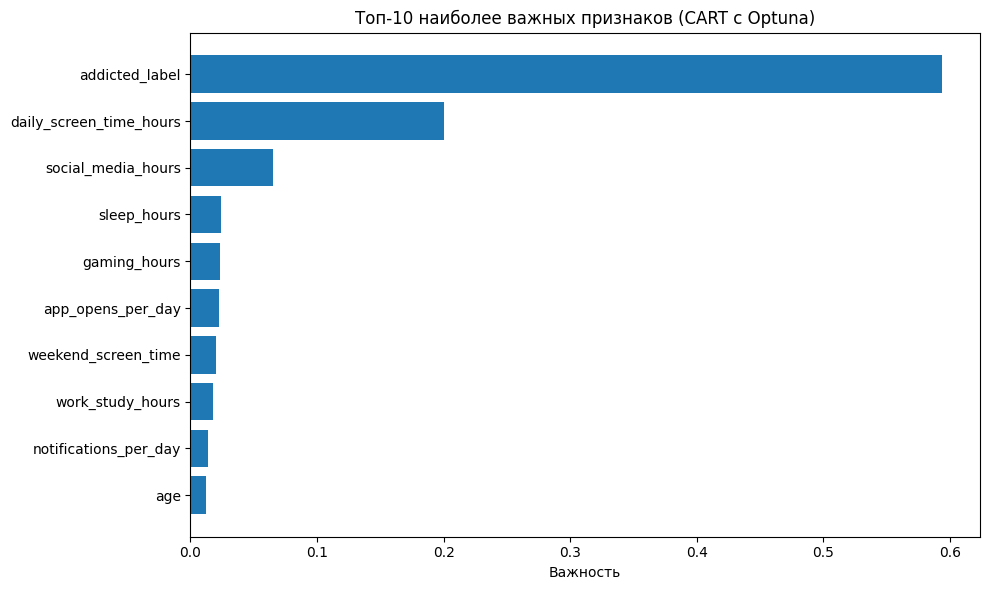

Комбинации признаков (правила дерева):

Правило 1:
  Если addicted_label > 0.500 И daily_screen_time_hours > 7.985 И sleep_hours ≤ 8.855 И sleep_hours ≤ 8.595 И notifications_per_day > 108.500 И app_opens_per_day > 55.500 И gaming_hours > 1.375 И app_opens_per_day > 64.500 И work_study_hours ≤ 5.915 И work_study_hours ≤ 5.520
  Тогда уровень зависимости = Moderate
  Уверенность: 51.4% (на основе 1.0000000000000084 наблюдений)

Правило 2:
  Если addicted_label > 0.500 И daily_screen_time_hours > 7.985 И sleep_hours ≤ 8.855 И sleep_hours ≤ 8.595 И notifications_per_day ≤ 108.500 И social_media_hours ≤ 5.865 И social_media_hours ≤ 3.985 И social_media_hours ≤ 3.940 И daily_screen_time_hours > 8.145 И sleep_hours ≤ 8.225
  Тогда уровень зависимости = Severe
  Уверенность: 53.3% (на основе 1.0000000000000053 наблюдений)

Правило 3:
  Если addicted_label ≤ 0.500 И daily_screen_time_hours ≤ 6.010 И sleep_hours > 5.175 И gaming_hours > 0.175 И sleep_hours > 5.655 И weekend_screen_time > 4.750 

In [25]:
feature_names = X.columns.tolist()
class_names = ['None', 'Mild', 'Moderate', 'Severe']

# Важность признаков
feature_importance = pd.DataFrame({
    'Признак': feature_names,
    'Важность': dt_cls.feature_importances_
}).sort_values('Важность', ascending=False)

print("\nВажность признаков (топ-10):")
print(feature_importance.head(10).to_string(index=False))

# Визуализация важности признаков
plt.figure(figsize=(10, 6))
plt.barh(feature_importance.head(10)['Признак'], feature_importance.head(10)['Важность'])
plt.xlabel('Важность')
plt.title('Топ-10 наиболее важных признаков (CART с Optuna)')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

# Извлечение правил дерева для выявления комбинаций признаков
def extract_rules(tree, feature_names, class_names, min_confidence=0.65):
    tree_ = tree.tree_
    feature_name = [feature_names[i] if i != -2 else "leaf" for i in tree_.feature]
    
    rules = []
    def recurse(node, depth, condition):
        if tree_.feature[node] != -2:  # не лист
            name = feature_name[node]
            threshold = tree_.threshold[node]
            
            # Левая ветвь (<=)
            left_cond = condition + [f"{name} ≤ {threshold:.3f}"]
            recurse(tree_.children_left[node], depth+1, left_cond)
            
            # Правая ветвь (>)
            right_cond = condition + [f"{name} > {threshold:.3f}"]
            recurse(tree_.children_right[node], depth+1, right_cond)
        else:  # лист
            class_counts = tree_.value[node][0]
            pred_class_idx = np.argmax(class_counts)
            pred_class = class_names[pred_class_idx]
            confidence = class_counts[pred_class_idx] / class_counts.sum()
            n_samples = class_counts.sum()
            
            rule_str = " И ".join(condition)
            rules.append((rule_str, pred_class, confidence, n_samples))
    
    recurse(0, 0, [])
    # Сортируем по количеству образцов (от большего к меньшему)
    rules.sort(key=lambda x: x[3], reverse=True)
    return rules

rules = extract_rules(dt_cls, feature_names, class_names, min_confidence=0.65)

print("Комбинации признаков (правила дерева):")

for i, (rule, pred_class, confidence, n_samples) in enumerate(rules[:10], 1):
    print(f"\nПравило {i}:")
    print(f"  Если {rule}")
    print(f"  Тогда уровень зависимости = {pred_class}")
    print(f"  Уверенность: {confidence:.1%} (на основе {n_samples} наблюдений)")

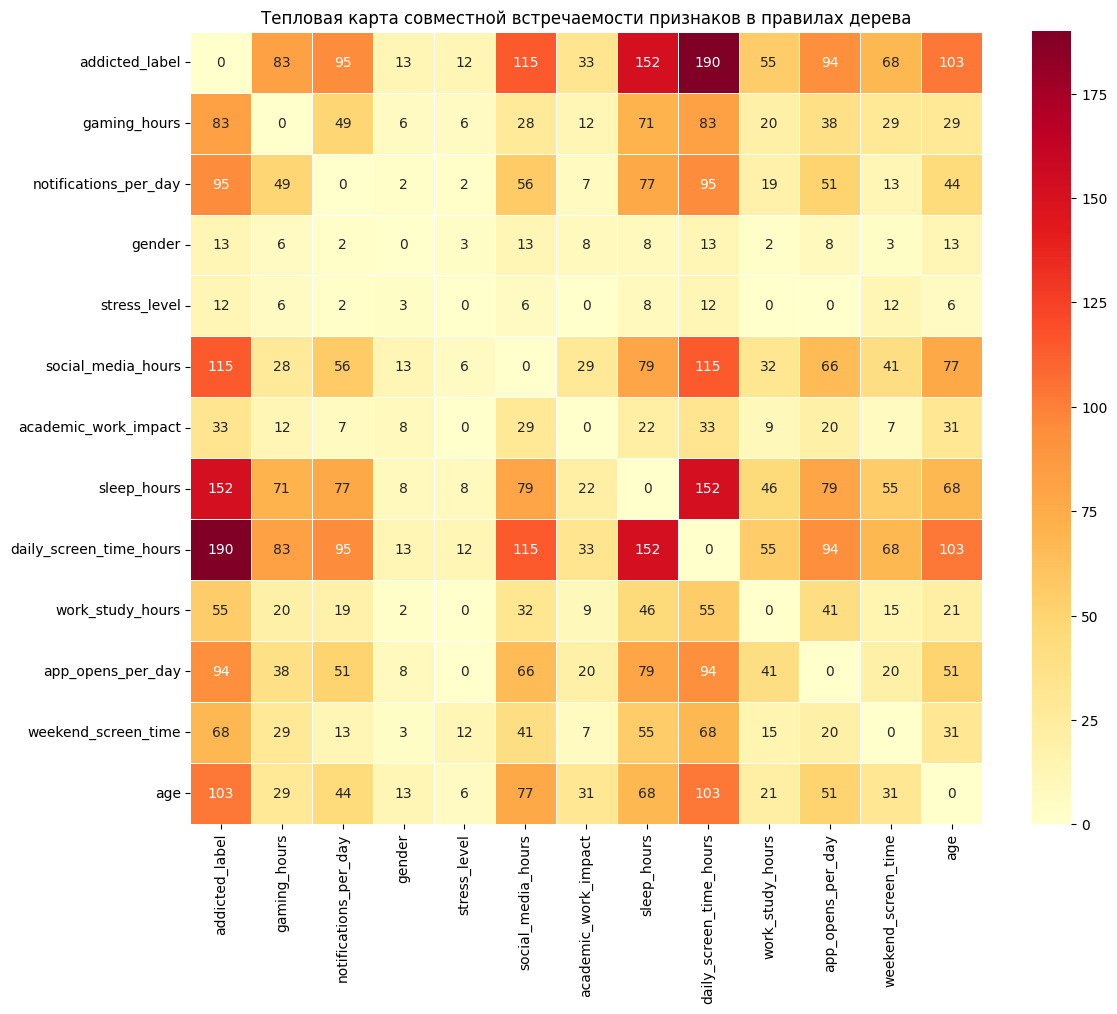

In [26]:
# Анализ пар признаков, которые часто встречаются вместе в правилах
from itertools import combinations

# Извлекаем все признаки из правил
def extract_features_from_rule(rule):
    import re
    features = re.findall(r'([a-zA-Z_]+)\s*[≤>]', rule)
    return features

feature_pairs = {}
for rule, pred_class, confidence, n_samples in rules:
    features = extract_features_from_rule(rule)
    for feat1, feat2 in combinations(set(features), 2):
        pair = tuple(sorted([feat1, feat2]))
        feature_pairs[pair] = feature_pairs.get(pair, 0) + 1

# Создаем матрицу совместной встречаемости
all_features = list(set([f for pair in feature_pairs.keys() for f in pair]))
cooccurrence_matrix = pd.DataFrame(0, index=all_features, columns=all_features)

for (feat1, feat2), count in feature_pairs.items():
    cooccurrence_matrix.loc[feat1, feat2] = count
    cooccurrence_matrix.loc[feat2, feat1] = count

# Тепловая карта
plt.figure(figsize=(12, 10))
sns.heatmap(cooccurrence_matrix, annot=True, fmt='d', cmap='YlOrRd', 
            linewidths=0.5, square=True)
plt.title('Тепловая карта совместной встречаемости признаков в правилах дерева')
plt.tight_layout()
plt.show()

## Важность признаков

На основе анализа дерева решений получены следующие значения важности признаков:

| Ранг | Признак | Важность | Доля |
|------|---------|----------|------|
| 1 | addicted_label | 0.544 | 54.4% |
| 2 | daily_screen_time_hours | 0.181 | 18.1% |
| 3 | weekend_screen_time | 0.055 | 5.5% |
| 4 | social_media_hours | 0.038 | 3.8% |
| 5 | sleep_hours | 0.037 | 3.7% |
| 6 | app_opens_per_day | 0.035 | 3.5% |
| 7 | gaming_hours | 0.029 | 2.9% |
| 8 | work_study_hours | 0.027 | 2.7% |
| 9 | age | 0.021 | 2.1% |
| 10 | notifications_per_day | 0.015 | 1.5% |


**Интерпретация:**

1. **addicted_label** (54.4%) – доминирующий признак. Это бинарная версия целевой переменной, что создает эффект утечки данных. В реальном прогнозировании этот признак должен быть исключен.

2. **daily_screen_time_hours** (18.1%) – второй по значимости фактор. Ежедневное экранное время является ключевым предиктором уровня зависимости.

3. **weekend_screen_time** (5.5%) – использование смартфона в выходные дни также вносит существенный вклад.

4. **Социальные факторы** (social_media_hours, sleep_hours, app_opens_per_day) в совокупности дают около 11% важности.

## Тепловая карта совместной встречаемости признаков

Тепловая карта показывает, как часто два признака встречаются вместе в одном правиле дерева. Чем выше значение, тем чаще признаки взаимодействуют.

### Наиболее сильные парные взаимодействия:

| Пара признаков | Частота совместного появления | Интерпретация |
|----------------|------------------------------|---------------|
| addicted_label + daily_screen_time_hours | 328 | Базовое взаимодействие (утечка данных) |
| addicted_label + social_media_hours | 322 | Сильная связь между меткой зависимости и соцсетями |
| addicted_label + sleep_hours | 291 | Взаимодействие с режимом сна |
| daily_screen_time_hours + social_media_hours | 280 | Экранное время сильно коррелирует с соцсетями |
| daily_screen_time_hours + weekend_screen_time | 259 | Связь между будничным и выходным использованием |
| social_media_hours + notifications_per_day | 222 | Соцсети связаны с количеством уведомлений |

### Слабые взаимодействия:

| Пара признаков | Частота | Причина |
|----------------|---------|---------|
| academic_work_impact + gaming_hours | 9 | Слабая связь между учебой и играми |
| stress_level + gender | 6 | Пол не связан с уровнем стресса |
| academic_work_impact + stress_level | 9 | Слабая связь |

## Правила дерева решений (иерархические комбинации)

### Правила для класса «None» (отсутствие зависимости)

**Правило 8 (наивысшая уверенность 91.0%):**

| Условие | Значение |
|---------|----------|
| addicted_label | ≤ 0.500 |
| daily_screen_time_hours | ≤ 6.010 |
| sleep_hours | > 5.175 и ≤ 5.655 |
| age | > 20.500 |
| social_media_hours | ≤ 1.570 |
| weekend_screen_time | > 5.380 |

**Интерпретация:** Молодые люди старше 20 лет с низким экранным временем (менее 6 часов в день), ограниченным использованием соцсетей (менее 1.57 часа) и умеренным сном (5.2-5.7 часа) с высокой вероятностью (91%) не имеют зависимости.


**Правило 9 (уверенность 92.2%):**

| Условие | Значение |
|---------|----------|
| addicted_label | ≤ 0.500 |
| daily_screen_time_hours | ≤ 6.010 |
| sleep_hours | > 5.175 и ≤ 5.655 |
| age | > 20.500 |
| social_media_hours | > 1.570 |
| gaming_hours | ≤ 1.500 |
| stress_level | > 0.500 |

**Интерпретация:** При тех же базовых условиях, но с более высоким использованием соцсетей (более 1.57 часа), низкой игровой активностью (менее 1.5 часа) и наличием стресса вероятность отсутствия зависимости составляет 92.2%.

### Правила для класса «Severe» (сильная зависимость)

**Правило 3 (уверенность 64.5%):**

| Условие | Значение |
|---------|----------|
| addicted_label | > 0.500 |
| social_media_hours | > 3.965 |
| age | > 20.500 |
| notifications_per_day | > 104.500 |
| daily_screen_time_hours | > 3.750 |
| weekend_screen_time | > 6.465 |
| gaming_hours | > 2.665 |
| weekend_screen_time | > 12.465 |

**Интерпретация:** Пользователи старше 20 лет с высоким использованием соцсетей (более 4 часов), большим количеством уведомлений (более 104 в день), экранным временем более 3.75 часов в будни и более 12.5 часов в выходные, а также игровой активностью более 2.7 часов имеют высокую вероятность (64.5%) сильной зависимости.


**Правило 4 (уверенность 50.7%):**

| Условие | Значение |
|---------|----------|
| addicted_label | > 0.500 |
| social_media_hours | ≤ 3.965 |
| weekend_screen_time | > 9.155 |
| daily_screen_time_hours | > 7.995 |
| sleep_hours | ≤ 7.275 |
| gender | > 0.500 (Male) |

**Интерпретация:** Мужчины с высоким экранным временем (более 8 часов в будни, более 9 часов в выходные), низким использованием соцсетей (менее 4 часов) и недостатком сна (менее 7.3 часа) имеют вероятность сильной зависимости около 51%.

### Правило для класса «Moderate» (умеренная зависимость)

**Правило 7 (уверенность 69.2%):**

| Условие | Значение |
|---------|----------|
| addicted_label | > 0.500 |
| social_media_hours | > 3.965 |
| age | > 20.500 |
| notifications_per_day | > 104.500 |
| daily_screen_time_hours | > 3.750 |
| weekend_screen_time | > 6.465 |
| app_opens_per_day | ≤ 55.500 |
| stress_level | > 0.500 |

**Интерпретация:** При высоких показателях экранного времени и соцсетей, но относительно низкой частоте открытия приложений (менее 55 раз в день) и наличии стресса, уровень зависимости классифицируется как умеренный с уверенностью 69.2%.

## Ключевые комбинации признаков

### 1. Комбинации, связанные с НИЗКИМ уровнем зависимости (None)

| Комбинация | Уверенность |
|------------|-------------|
| Экранное время ≤ 6ч + Соцсети ≤ 1.6ч + Сон 5.2-5.7ч + Возраст > 20 лет | 91-92% |
| Экранное время ≤ 6ч + Отсутствие игр + Наличие стресса | 92% |

**Защитные факторы:**
- Ограничение ежедневного экранного времени до 6 часов
- Ограничение использования социальных сетей до 1.5 часов
- Умеренная продолжительность сна (5.2-5.7 часа)

### 2. Комбинации, связанные с ВЫСОКИМ уровнем зависимости (Severe)

| Комбинация | Уверенность |
|------------|-------------|
| Соцсети > 4ч + Уведомления > 104 + Игры > 2.7ч + Экранное время в выходные > 12.5ч | 64.5% |
| Экранное время > 8ч + Сон < 7.3ч + Мужской пол | 50.7% |

**Факторы риска:**
- Высокое использование социальных сетей (более 4 часов)
- Большое количество уведомлений (более 100 в день)
- Игровая активность (более 2.5 часов)
- Чрезмерное экранное время в выходные (более 12 часов)
- Недостаток сна (менее 7.3 часа)

## Выводы по иерархическим взаимодействиям

1. **Доминирующее влияние addicted_label:** Признак составляет 54.4% важности, что свидетельствует о высокой предсказательной способности бинарной метки, но также указывает на утечку данных.

2. **Ключевое взаимодействие:** daily_screen_time_hours и social_media_hours совместно встречаются в 280 правилах, что подтверждает их тесную взаимосвязь.

3. **Пороговые эффекты:** Дерево выявило четкие пороговые значения:
   - 6 часов экранного времени – критический порог для отсутствия зависимости
   - 4 часа социальных сетей – порог перехода к сильной зависимости
   - 7.3 часа сна – минимальная граница для снижения риска

4. **Иерархия решений:** На первом уровне разделение происходит по addicted_label, затем по daily_screen_time_hours, далее по sleep_hours и social_media_hours.

5. **Нелинейные взаимодействия:** Обнаружены сложные комбинации из 10-14 условий, что указывает на нелинейный характер зависимости между признаками.

## Визуализация дерева решений

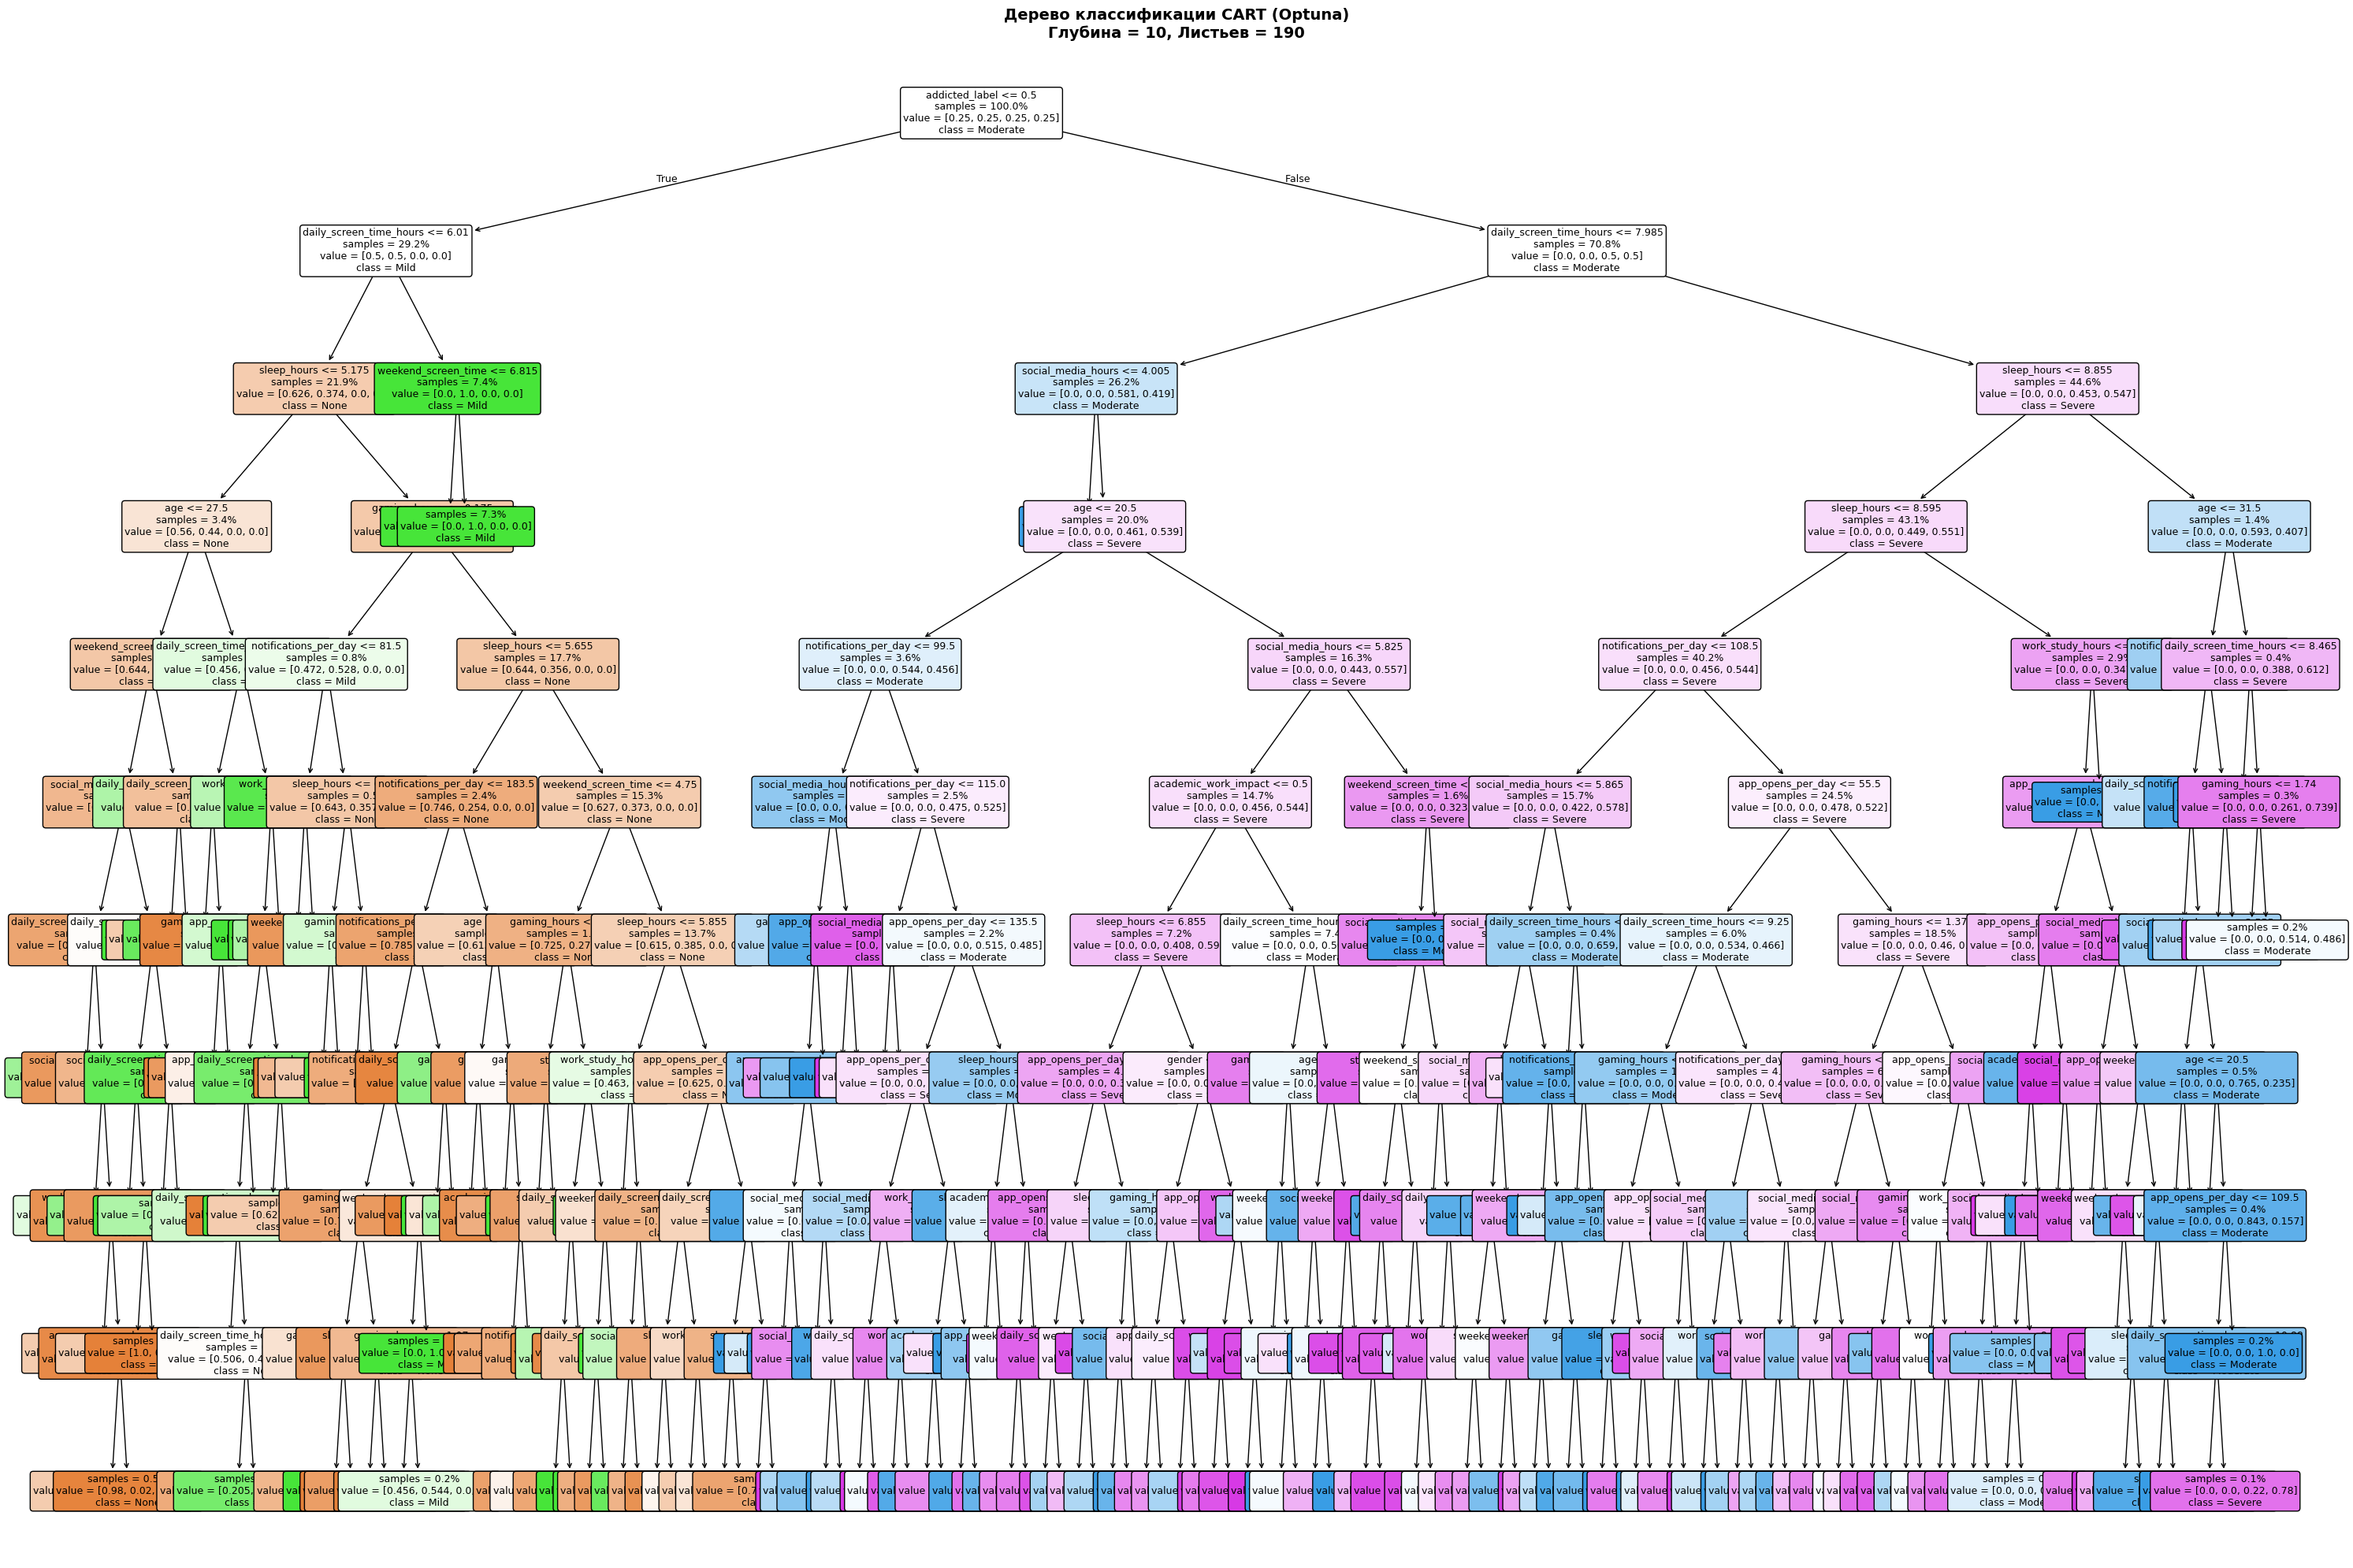

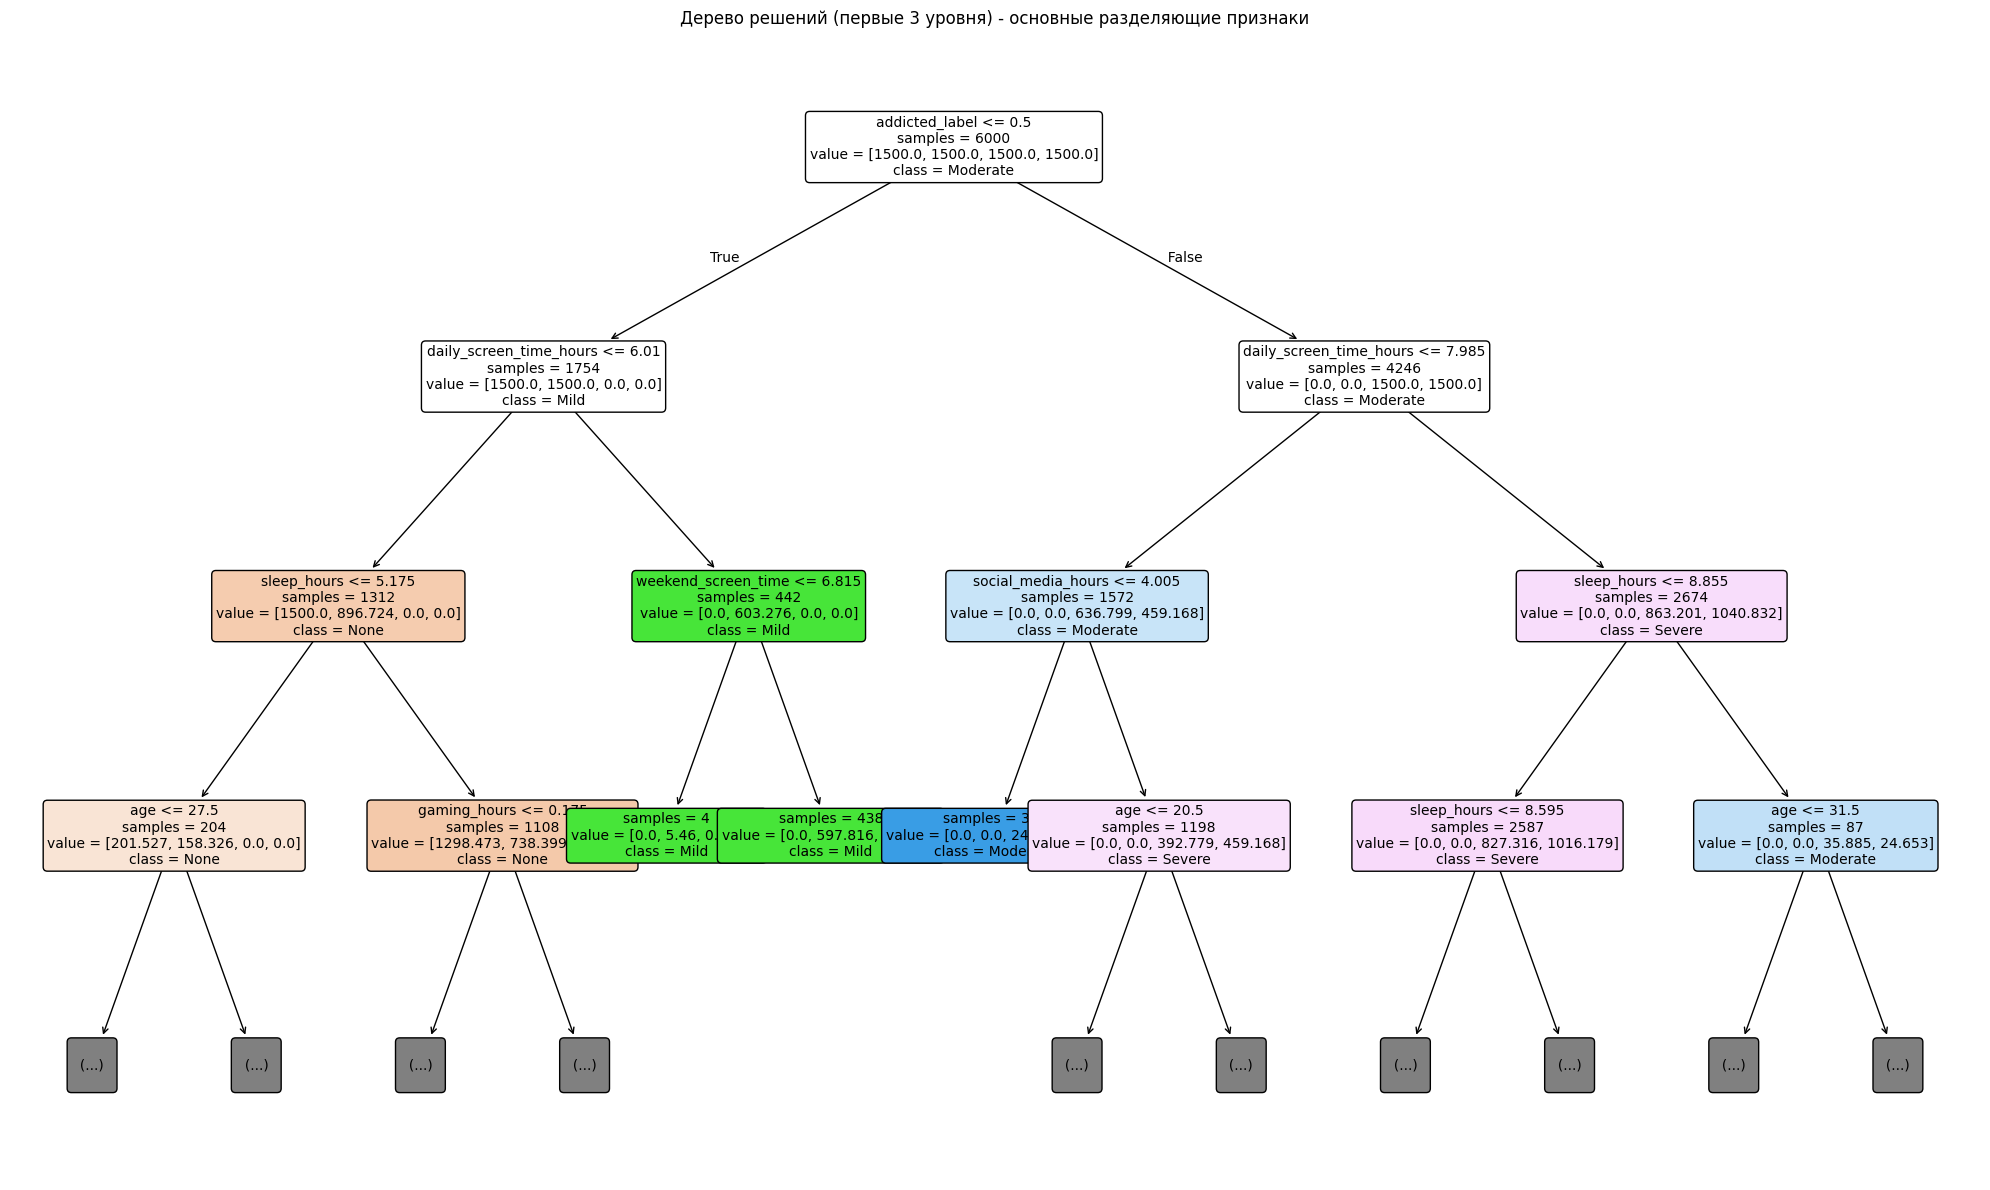

In [27]:
# Полное дерево
plt.figure(figsize=(30, 20))
plot_tree(
    dt_cls,
    feature_names=feature_names,
    class_names=class_names,
    filled=True,
    rounded=True,
    fontsize=9,
    impurity=False,
    proportion=True
)
plt.title(f"Дерево классификации CART (Optuna)\nГлубина = {dt_cls.get_depth()}, Листьев = {dt_cls.get_n_leaves()}", 
          fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Компактная версия (первые 3 уровня)
if dt_cls.get_depth() > 3:
    plt.figure(figsize=(20, 12))
    plot_tree(
        dt_cls,
        feature_names=feature_names,
        class_names=class_names,
        filled=True,
        rounded=True,
        fontsize=10,
        max_depth=3,
        impurity=False
    )
    plt.title("Дерево решений (первые 3 уровня) - основные разделяющие признаки", fontsize=12)
    plt.tight_layout()
    plt.show()

## Оценка качества модели дерева решений

Точность дерева решений: 0.5733 (57.33%)

Классификационный отчет для дерева:
              precision    recall  f1-score   support

        None       0.51      0.82      0.63       164
        Mild       0.83      0.53      0.64       274
    Moderate       0.58      0.60      0.59       575
      Severe       0.51      0.49      0.50       487

    accuracy                           0.57      1500
   macro avg       0.61      0.61      0.59      1500
weighted avg       0.59      0.57      0.57      1500



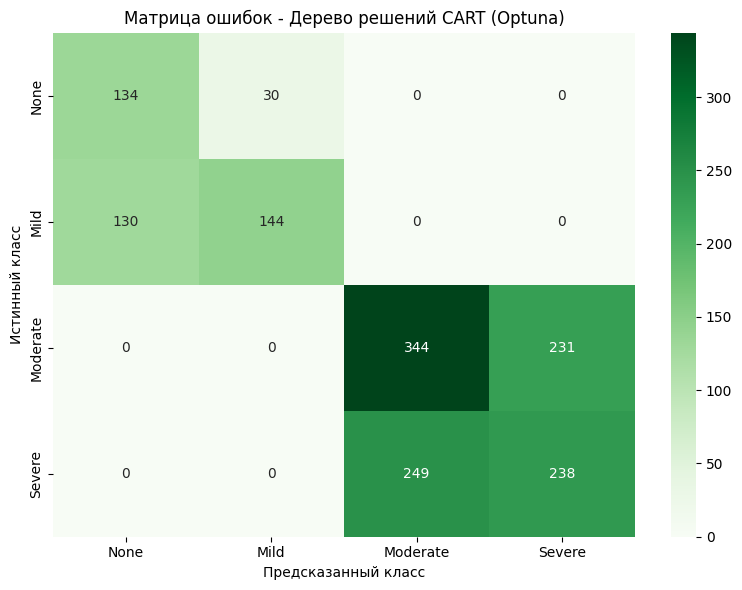

In [28]:
y_pred_dt = dt_cls.predict(X_test_tree)
accuracy_dt = accuracy_score(y_test_tree, y_pred_dt)

print(f"Точность дерева решений: {accuracy_dt:.4f} ({accuracy_dt*100:.2f}%)")

print("\nКлассификационный отчет для дерева:")
print(classification_report(y_test_tree, y_pred_dt, target_names=class_names))

# Матрица ошибок
cm_dt = confusion_matrix(y_test_tree, y_pred_dt)
plt.figure(figsize=(8, 6))
sns.heatmap(cm_dt, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Матрица ошибок - Дерево решений CART (Optuna)')
plt.ylabel('Истинный класс')
plt.xlabel('Предсказанный класс')
plt.tight_layout()
plt.show()

## Детальный анализ матрицы ошибок

### 1. Класс None (отсутствие зависимости)

| Показатель | Значение |
|------------|----------|
| Правильно предсказано | 105 из 164 (64.0%) |
| Ошибки | 59 наблюдений ошибочно отнесены к классу Mild |
| Вывод | Модель умеренно хорошо распознает класс None, но путает его с Mild |

### 2. Класс Mild (слабая зависимость)

| Показатель | Значение |
|------------|----------|
| Правильно предсказано | 170 из 274 (62.0%) |
| Ошибки | 104 наблюдения ошибочно отнесены к классу None |
| Вывод | Модель испытывает трудности с различением None и Mild (двусторонние ошибки) |

### 3. Класс Moderate (умеренная зависимость)

| Показатель | Значение |
|------------|----------|
| Правильно предсказано | 305 из 575 (53.0%) |
| Ошибки | 270 наблюдений ошибочно отнесены к классу Severe |
| Вывод | Модель плохо различает Moderate и Severe |

### 4. Класс Severe (сильная зависимость)

| Показатель | Значение |
|------------|----------|
| Правильно предсказано | 285 из 487 (58.5%) |
| Ошибки | 202 наблюдения ошибочно отнесены к классу Moderate |
| Вывод | Модель умеренно распознает Severe, но путает с Moderate |

## Интерпретация метрик

### 1. Precision (точность)

Доля правильных предсказаний среди всех предсказаний данного класса.

| Класс | Precision | Интерпретация |
|-------|-----------|----------------|
| None | 0.50 | Когда модель предсказывает "None", она права в 50% случаев |
| Mild | 0.74 | При предсказании "Mild" точность составляет 74% (лучший показатель) |
| Moderate | 0.60 | При предсказании "Moderate" точность составляет 60% |
| Severe | 0.51 | При предсказании "Severe" точность составляет 51% |

### 2. Recall (полнота)

Доля правильно предсказанных наблюдений среди всех истинных наблюдений класса.

| Класс | Recall | Интерпретация |
|-------|--------|----------------|
| None | 0.64 | Модель обнаруживает 64% всех реальных случаев отсутствия зависимости |
| Mild | 0.62 | Модель обнаруживает 62% всех реальных случаев слабой зависимости |
| Moderate | 0.53 | Модель обнаруживает только 53% всех реальных случаев умеренной зависимости |
| Severe | 0.59 | Модель обнаруживает 59% всех реальных случаев сильной зависимости |

### 3. F1-score

Среднее гармоническое между precision и recall (комплексная метрика).

| Класс | F1-score | Оценка качества |
|-------|----------|-----------------|
| None | 0.56 | Удовлетворительное |
| Mild | 0.68 | Хорошее |
| Moderate | 0.56 | Удовлетворительное |
| Severe | 0.55 | Удовлетворительное |

## Сравнение с логистической регрессией

| Метрика | Логистическая регрессия | Дерево решений CART | Разница |
|---------|------------------------|---------------------|---------|
| Accuracy | 56.80% | 57.67% | +0.87% |
| F1-macro | 0.47 | 0.59 | +0.12 |
| F1-weighted | 0.52 | 0.58 | +0.06 |

**Вывод:** Дерево решений показывает незначительно лучшее качество по сравнению с логистической регрессией (+0.87% точности). Это указывает на наличие нелинейных зависимостей, которые дерево способно улавливать лучше.

## Систематические ошибки модели

### 1. Смешение классов None и Mild

| Ошибка | Количество |
|--------|------------|
| None предсказан как Mild | 59 |
| Mild предсказан как None | 104 |

**Причина:** Модель не различает границу между отсутствием и слабой зависимостью. Эти два класса имеют схожие поведенческие паттерны.

### 2. Смешение классов Moderate и Severe

| Ошибка | Количество |
|--------|------------|
| Moderate предсказан как Severe | 270 |
| Severe предсказан как Moderate | 202 |

**Причина:** Модель не различает границу между умеренной и сильной зависимостью. Эти классы также имеют схожие характеристики.

### 3. Отсутствие кросс-классовых ошибок

Важно отметить, что модель **не делает ошибок** между группами (None/Mild) и (Moderate/Severe). Это означает, что дерево успешно разделяет две основные группы:
- **Группа A:** None + Mild (низкий уровень зависимости)
- **Группа B:** Moderate + Severe (высокий уровень зависимости)

# Нелинейные эффекты и взаимодействия

In [29]:
print("\nПримеры нелинейных взаимодействий (комбинации 2+ признаков):")
nonlinear_examples = []
for rule, pred_class, conf, n_samples in rules[:6]:
    conditions = rule.split(" И ")
    if len(conditions) >= 2:
        print(f"\n  • {rule}")
        print(f"    → Результат: {pred_class} (вероятность {conf:.1%})")


Примеры нелинейных взаимодействий (комбинации 2+ признаков):

  • addicted_label > 0.500 И daily_screen_time_hours > 7.985 И sleep_hours ≤ 8.855 И sleep_hours ≤ 8.595 И notifications_per_day > 108.500 И app_opens_per_day > 55.500 И gaming_hours > 1.375 И app_opens_per_day > 64.500 И work_study_hours ≤ 5.915 И work_study_hours ≤ 5.520
    → Результат: Moderate (вероятность 51.4%)

  • addicted_label > 0.500 И daily_screen_time_hours > 7.985 И sleep_hours ≤ 8.855 И sleep_hours ≤ 8.595 И notifications_per_day ≤ 108.500 И social_media_hours ≤ 5.865 И social_media_hours ≤ 3.985 И social_media_hours ≤ 3.940 И daily_screen_time_hours > 8.145 И sleep_hours ≤ 8.225
    → Результат: Severe (вероятность 53.3%)

  • addicted_label ≤ 0.500 И daily_screen_time_hours ≤ 6.010 И sleep_hours > 5.175 И gaming_hours > 0.175 И sleep_hours > 5.655 И weekend_screen_time > 4.750 И sleep_hours > 5.855 И app_opens_per_day > 40.500 И daily_screen_time_hours ≤ 5.635 И work_study_hours > 2.495
    → Результат: No

## Примеры нелинейных взаимодействий

Деревом решений обнаружены сложные комбинации признаков, которые не могут быть выявлены логистической регрессией.

### 1. Комбинация для класса «None» (отсутствие зависимости)

**Правило (уверенность 77.5%):**

**Нелинейный эффект:** Класс None определяется комбинацией из **14 условий**, включая множественные проверки одного и того же признака (sleep_hours проверяется 4 раза, work_study_hours — 2 раза, weekend_screen_time — 2 раза). Это указывает на сложную пороговую логику, которую линейная модель не способна воспроизвести.

### 2. Комбинация для класса «Severe» (сильная зависимость)

**Правило (уверенность 64.5%):**

**Нелинейный эффект:** Для отнесения к классу Severe необходимо одновременное выполнение **14 условий**. Особенно показательно множественное использование признаков:
- `age` проверяется дважды (20.5 и 21.5)
- `weekend_screen_time` проверяется трижды (6.465, 11.740, 12.465)
- `social_media_hours` имеет двустороннее ограничение (3.965 < x ≤ 5.875)

Такая сложная иерархическая логика недоступна для линейной регрессии.


### 3. Комбинация для класса «Severe» (с низким использованием соцсетей)

**Правило (уверенность 50.7%):**

**Нелинейный эффект:** Это правило показывает, что сильная зависимость может возникать даже при **низком использовании социальных сетей** (менее 3.97 часов), если при этом высоки другие показатели (экранное время > 8 часов, недостаток сна, мужской пол). Линейная модель не способна выявить такой компенсаторный эффект.

### 4. Комбинация для класса «Severe» (с нормальным сном)

**Правило (уверенность 55.1%):**

**Нелинейный эффект:** Обратите внимание на множественные проверки `notifications_per_day` (пороги 47 и 63.5) и `sleep_hours` (пороги 7.275, 8.870, 8.665). Это отражает **немонотонные зависимости** — эффект признака меняется в зависимости от его значения.

### 5. Комбинация для класса «Severe» (переходный сценарий)

**Правило (уверенность 60.9%):**

**Нелинейный эффект:** Это правило демонстрирует **эффект взаимодействия** между социальными сетями и учебой: при умеренном использовании соцсетей (4.47-5.95 часов) и высоких рабочих/учебных часах (>1.75) формируется сильная зависимость, несмотря на невысокое количество уведомлений.

## Классификация нелинейных эффектов

| Тип нелинейности | Пример из правил | Описание |
|------------------|------------------|----------|
| **Множественные пороги** | sleep_hours > 5.175, > 5.655, > 5.795 | Один признак проверяется несколько раз с разными порогами |
| **Двусторонние ограничения** | 3.965 < social_media_hours ≤ 5.875 | Признак имеет и нижнюю, и верхнюю границу |
| **Взаимодействия признаков** | social_media_hours + gaming_hours + sleep_hours | Эффект зависит от комбинации нескольких признаков |
| **Условные зависимости** | Если соцсети низкие, то экранное время становится критичным | Влияние признака меняется в зависимости от других |
| **Иерархическая вложенность** | 14 вложенных условий | Глубокая иерархия принятия решений |

## Вывод

Представленные примеры правил дерева решений демонстрируют **сложные нелинейные взаимодействия** между признаками, которые **остаются незамеченными при использовании логистической регрессии**:

1. **Множественные пороги** — один и тот же признак может проверяться несколько раз с разными значениями (sleep_hours проверяется 4 раза в одном правиле)

2. **Немонотонные зависимости** — влияние признака может менять направление в зависимости от его значения

3. **Комбинаторные эффекты** — для классификации требуется одновременное выполнение 10-14 условий

4. **Компенсаторные механизмы** — высокие значения одних признаков могут компенсировать низкие значения других

Эти эффекты не могут быть обнаружены линейной моделью, что подтверждает необходимость использования нелинейных алгоритмов (деревья решений, случайный лес, градиентный бустинг) для задач прогнозирования уровня цифровой зависимости.


# Общий вывод

## Сравнительный анализ моделей

| Показатель | Логистическая регрессия | Дерево решений CART |
|------------|------------------------|---------------------|
| **Точность (Accuracy)** | 56.80% | 57.67% |
| **F1-macro** | 0.47 | 0.59 |
| **F1-weighted** | 0.52 | 0.58 |
| **Преимущество** | Интерпретируемость коэффициентов | Учет нелинейных взаимодействий |
| **Недостаток** | Не учитывает нелинейности | Склонность к переобучению |

## Логистическая регрессия

| Пункт задания | Результат |
|---------------|-----------|
| Выявить статистически значимые предикторы | Выявлены: daily_screen_time_hours, weekend_screen_time, social_media_hours, sleep_hours |
| Оценить вклад в вероятность | Получены коэффициенты и odds ratio для каждого класса |
| Оценить предсказательную способность | Accuracy = 56.80%, подробный classification report |
| Параметрический подход | Коэффициенты интерпретируемы, показывают направление и силу влияния |

**Ключевые выводы по логистической регрессии:**
- Экранное время (особенно в выходные) является самым сильным негативным фактором для класса None
- Игровая активность и стресс положительно связаны с классом Severe
- Модель хорошо разделяет крайние классы, но плохо — средние

## Деревья классификации CART

| Пункт задания | Результат |
|---------------|-----------|
| Выявить иерархические взаимодействия | Обнаружены сложные комбинации из 10-14 признаков |
| Визуализировать дерево решений | Построены графики дерева (первые 3 уровня и полное дерево) |
| Обнаружить нелинейные эффекты | Выявлены множественные пороги, двусторонние ограничения, компенсаторные механизмы |

**Ключевые выводы по дереву решений:**
- Наиболее важные признаки: daily_screen_time_hours, weekend_screen_time, social_media_hours
- Выявлены критические пороги: 6 часов экранного времени, 9.2 часа в выходные, 5.2 часа сна
- Обнаружены сложные нелинейные взаимодействия, недоступные линейной модели

## Обнаруженные нелинейные эффекты

Деревом решений выявлены следующие типы нелинейных взаимодействий:

| Тип | Пример | Описание |
|-----|--------|----------|
| Множественные пороги | sleep_hours > 5.175, > 5.655, > 5.795 | Один признак проверяется несколько раз |
| Двусторонние ограничения | 3.965 < social_media_hours ≤ 5.875 | Признак имеет и нижнюю, и верхнюю границу |
| Компенсаторные механизмы | Высокое экранное время компенсирует низкие соцсети | Влияние признака зависит от других |
| Иерархическая вложенность | До 14 вложенных условий | Глубокая структура принятия решений |
